0
              YEAR          DOY          T2M      T2M_MAX      T2M_MIN  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000   
mean   2020.131451   180.121227    28.759007    36.773914    21.508510   
min    2015.000000     1.000000    13.180000    21.040000     5.930000   
25%    2017.000000    86.000000    25.560000    33.730000    17.497500   
50%    2020.000000   179.000000    29.160000    37.020000    22.890000   
75%    2023.000000   272.000000    32.510000    40.330000    25.430000   
max    2026.000000   366.000000    37.990000    45.960000    32.170000   
std       3.248907   106.294767     4.681305     4.400065     5.091142   

         T2M_RANGE  PRECTOTCORR         RH2M         WS2M     WS2M_MAX  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000   
mean     15.265404     0.643875    31.359192     3.484253     5.157378   
min       3.420000     0.000000     4.690000     0.610000     1.030000   
25%      13.280000     0.000000    

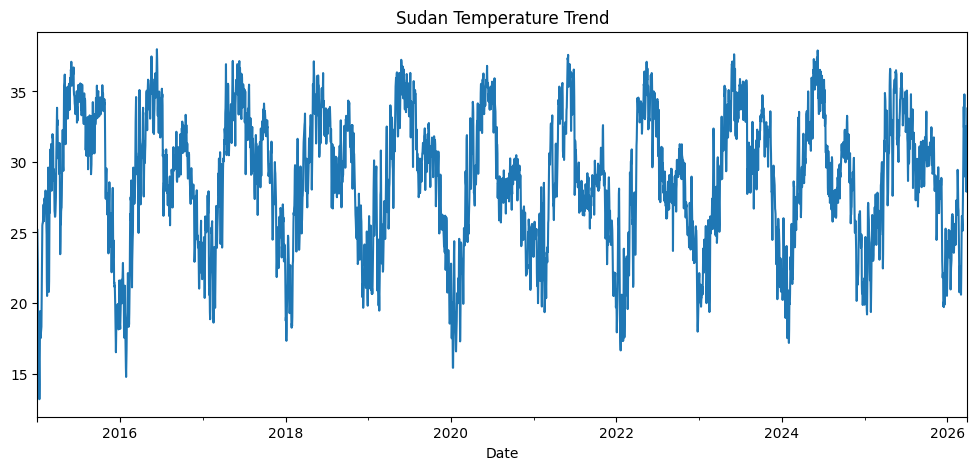

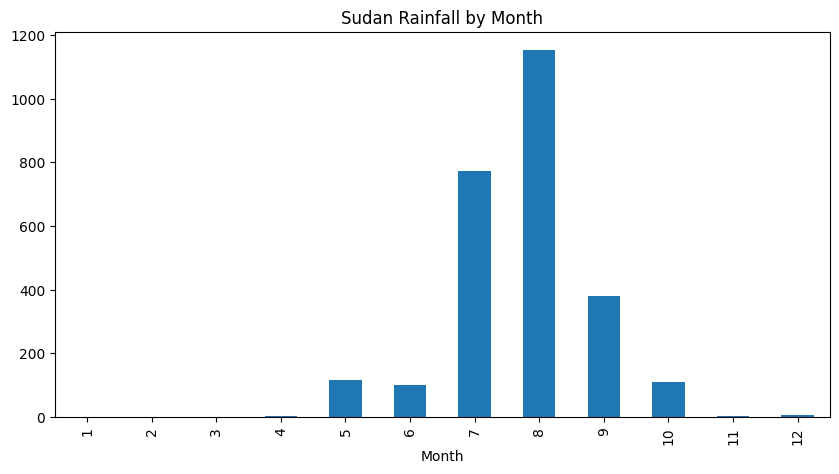

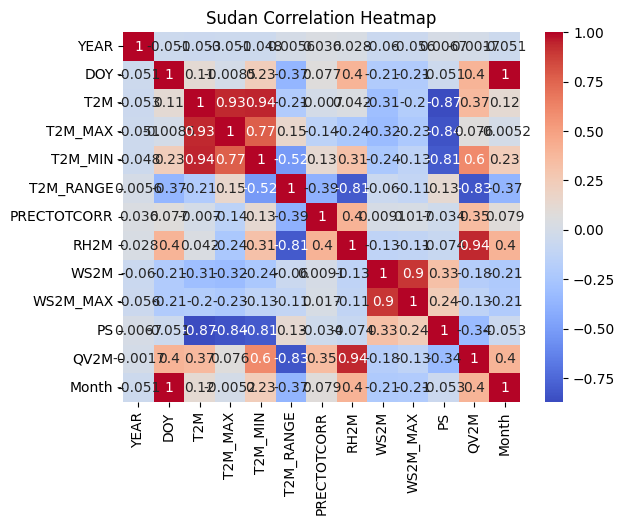

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/sudan.csv")

df["Country"] = "Sudan"

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.replace(-999, np.nan, inplace=True)

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print(df.describe())

print(df.isna().sum())

df.ffill(inplace=True)

monthly_temp = df.groupby("Date")["T2M"].mean()

plt.figure(figsize=(12,5))
monthly_temp.plot()
plt.title("Sudan Temperature Trend")
plt.show()

monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")
plt.title("Sudan Rainfall by Month")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Sudan Correlation Heatmap")
plt.show()
